In [1]:
import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image

cwd = Path.cwd().resolve()
if (cwd / "data").is_dir():
    ROOT = cwd
elif (cwd.parent / "data").is_dir():
    ROOT = cwd.parent
else:
    raise FileNotFoundError(f"Could not find data/ from {cwd}")

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from gng import GrowingNeuralGas

DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "gng" / "results_gng"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (450, 450)
MAX_NEURONS = [16, 64, 256]
EPOCHS = 5
LR_WINNER = 0.05
LR_NEIGHBOR = 0.0006
MAX_EDGE_AGE = 50
LAMBDA_STEPS = 100
ALPHA = 0.5
BETA = 0.995
RANDOM_SEED = 42

METRIC_FIELDS = [
    "image",
    "neurons",
    "quantization_error",
    "mse",
    "psnr",
    "original_colors",
    "used_colors",
]

image_paths = sorted(
    path
    for path in DATA_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
)

print(f"{len(image_paths)} images from {DATA_DIR}")
for path in image_paths:
    print(path.name)
print(f"resize: {IMAGE_SIZE[0]}x{IMAGE_SIZE[1]}")
print(f"neurons: {', '.join(str(count) for count in MAX_NEURONS)}")
print(f"epochs: {EPOCHS}")
print(f"metrics: {RESULTS_DIR / 'metrics.csv'}")


5 images from /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/data
image1.jpg
image2.jpg
image3.jpg
image4.jpg
image5.jpg
resize: 450x450
neurons: 16, 64, 256
epochs: 5
metrics: /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/metrics.csv


In [2]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    image = image.resize(IMAGE_SIZE, Image.Resampling.LANCZOS)
    pixels = np.asarray(image)
    samples = pixels.reshape(-1, 3).astype(np.float32) / 255.0
    return image, pixels, samples


def train_gng(samples, max_neurons):
    gng = GrowingNeuralGas(
        input_dim=3,
        max_neurons=max_neurons,
        lr_winner=LR_WINNER,
        lr_neighbor=LR_NEIGHBOR,
        max_edge_age=MAX_EDGE_AGE,
        lambda_steps=LAMBDA_STEPS,
        alpha=ALPHA,
        beta=BETA,
        seed=RANDOM_SEED,
    )
    gng.fit(samples, epochs=EPOCHS, shuffle=True)
    return gng


def measure(gng, samples, pixels):
    indices = gng.predict(samples)
    quantized = np.clip(gng.weights[indices], 0, 1)
    quantized_image = quantized.reshape(pixels.shape)

    colors = np.clip(gng.weights, 0, 1)
    side = int(np.ceil(np.sqrt(len(colors))))
    pad = side * side - len(colors)
    if pad:
        colors = np.vstack([colors, np.zeros((pad, colors.shape[1]), dtype=colors.dtype)])
    palette = colors.reshape(side, side, 3)

    mse = float(np.mean((samples - quantized) ** 2))
    psnr = float(10 * np.log10(1.0 / mse)) if mse > 0 else float("inf")
    quantization_error = gng.quantization_error(samples)

    original_colors = int(len(np.unique(pixels.reshape(-1, 3), axis=0)))
    used = (quantized * 255).round().astype(np.uint8)
    used_colors = int(len(np.unique(used, axis=0)))

    return {
        "quantization_error": quantization_error,
        "mse": mse,
        "psnr": psnr,
        "original_colors": original_colors,
        "used_colors": used_colors,
        "quantized_image": quantized_image,
        "palette": palette,
        "n_nodes": gng.n_nodes,
    }


def save_metrics(metrics):
    metrics_path = RESULTS_DIR / "metrics.csv"
    with metrics_path.open("w", newline="") as file:
        writer = csv.DictWriter(file, fieldnames=METRIC_FIELDS)
        writer.writeheader()
        writer.writerows(metrics)
    return metrics_path


def load_metrics(path):
    with path.open(newline="") as file:
        rows = list(csv.DictReader(file))
    for row in rows:
        row["neurons"] = int(row["neurons"])
        row["quantization_error"] = float(row["quantization_error"])
        row["mse"] = float(row["mse"])
        row["psnr"] = float(row["psnr"])
        row["original_colors"] = int(row["original_colors"])
        row["used_colors"] = int(row["used_colors"])
    return rows


def show_image_results(image, stem, runs):
    n_cols = len(runs) + 1
    fig, axes = plt.subplots(
        2,
        n_cols,
        figsize=(3.5 * n_cols, 7.2),
        layout="constrained",
        gridspec_kw={"height_ratios": [1.35, 0.85]},
    )

    axes[0, 0].imshow(image)
    axes[0, 0].set_title(f"Original\n{runs[0]['original_colors']} colors")
    axes[0, 0].axis("off")
    axes[1, 0].axis("off")

    for column, run in enumerate(runs, start=1):
        neurons = run["neurons"]
        axes[0, column].imshow(run["quantized_image"])
        axes[0, column].set_title(f"{neurons} neurons\nPSNR {run['psnr']:.2f} dB")
        axes[0, column].axis("off")
        axes[1, column].imshow(run["palette"], interpolation="nearest")
        axes[1, column].set_title(f"Palette {neurons}\n{run['used_colors']} colors")
        axes[1, column].axis("off")

    fig.suptitle(stem, fontsize=14)
    figure_path = RESULTS_DIR / f"{stem}.png"
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    return figure_path


# Train Growing Neural Gas

Each image is resized to 450×450. A GNG codebook is trained with 16, 64, and 256 units. One epoch presents every pixel once, which is enough to insert 256 units when a new unit is added every 100 samples. The remaining epochs refine those colors. The result figure is shown when that image finishes all three codebooks. Metrics are written to `gng/results_gng/metrics.csv` after every training.



=== image1.jpg (450, 450) samples=(202500, 3) ===

training 16 neurons
alive units: 16
quantization error: 0.0636
MSE: 0.001923
PSNR: 27.16 dB
colors: 88207 -> 16

training 64 neurons
alive units: 64
quantization error: 0.0322
MSE: 0.000480
PSNR: 33.19 dB
colors: 88207 -> 64

training 256 neurons
alive units: 256
quantization error: 0.0207
MSE: 0.000183
PSNR: 37.37 dB
colors: 88207 -> 244


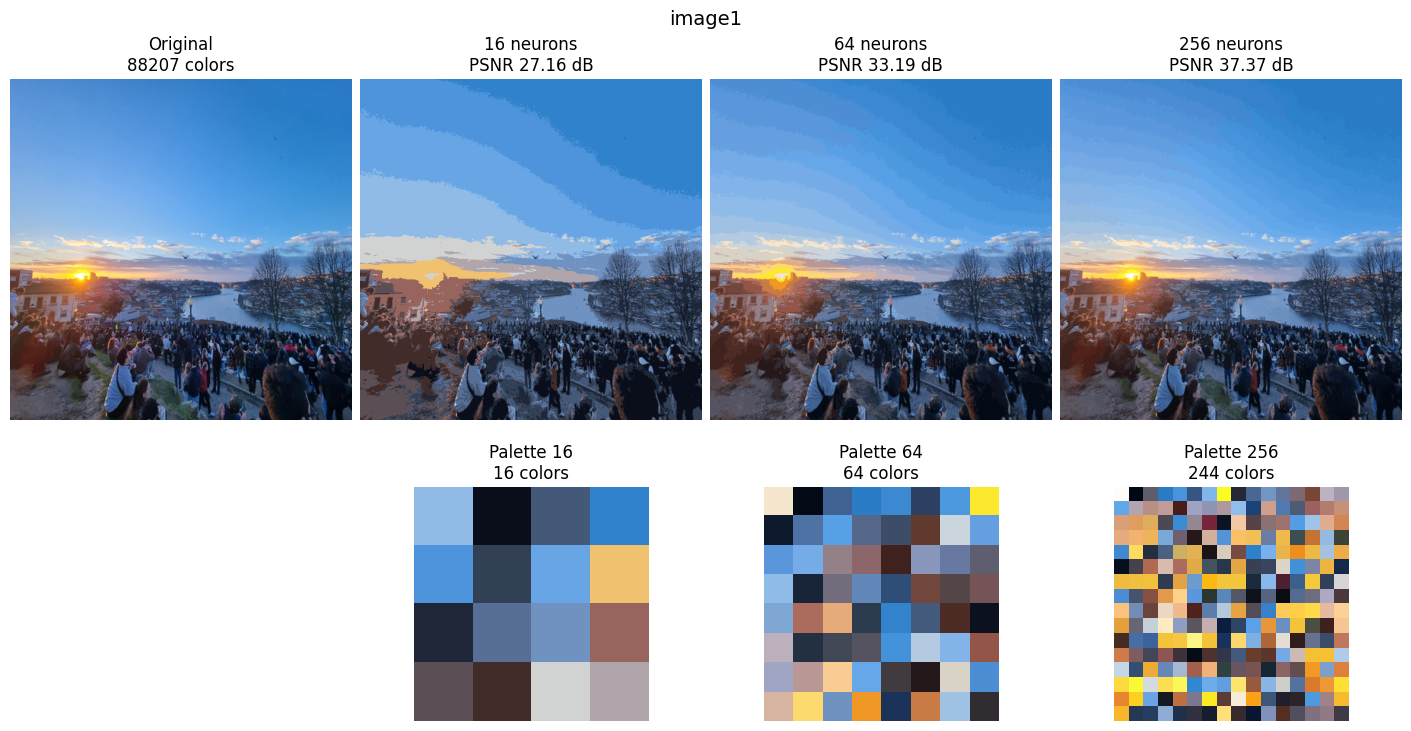

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/image1.png

=== image2.jpg (450, 450) samples=(202500, 3) ===

training 16 neurons
alive units: 16
quantization error: 0.0550
MSE: 0.001303
PSNR: 28.85 dB
colors: 81581 -> 16

training 64 neurons
alive units: 64
quantization error: 0.0285
MSE: 0.000340
PSNR: 34.68 dB
colors: 81581 -> 64

training 256 neurons
alive units: 256
quantization error: 0.0170
MSE: 0.000118
PSNR: 39.28 dB
colors: 81581 -> 251


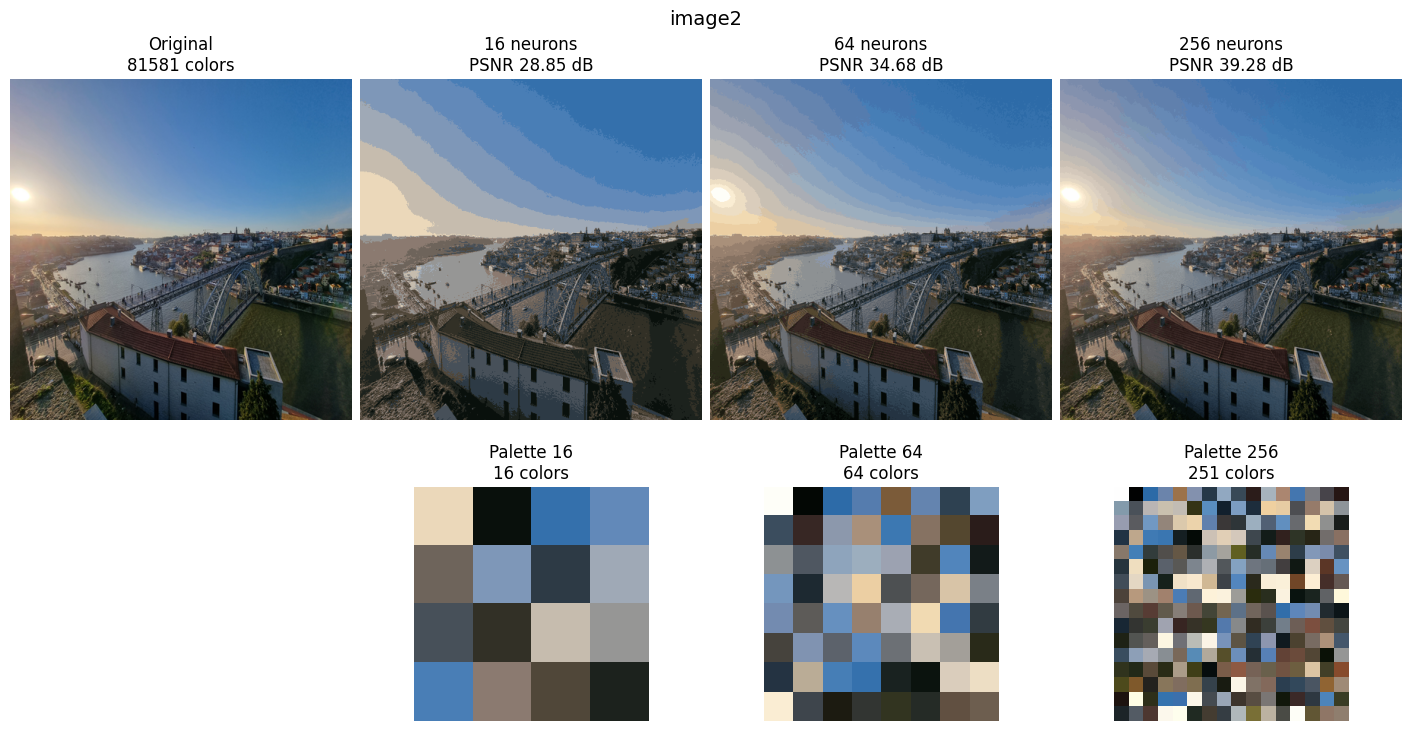

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/image2.png

=== image3.jpg (450, 450) samples=(202500, 3) ===

training 16 neurons
alive units: 16
quantization error: 0.0518
MSE: 0.001209
PSNR: 29.17 dB
colors: 73373 -> 16

training 64 neurons
alive units: 64
quantization error: 0.0270
MSE: 0.000313
PSNR: 35.04 dB
colors: 73373 -> 64

training 256 neurons
alive units: 256
quantization error: 0.0153
MSE: 0.000099
PSNR: 40.05 dB
colors: 73373 -> 256


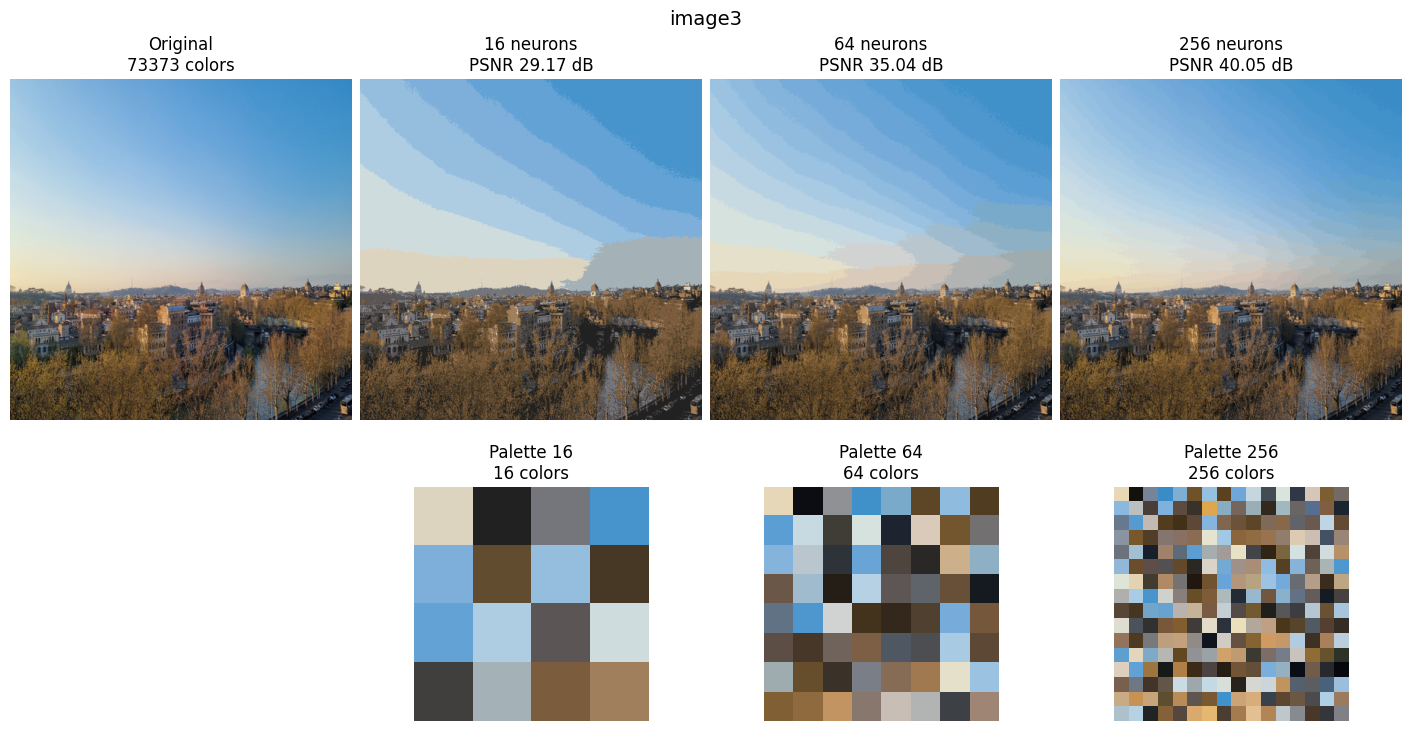

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/image3.png

=== image4.jpg (450, 450) samples=(202500, 3) ===

training 16 neurons
alive units: 16
quantization error: 0.0565
MSE: 0.001428
PSNR: 28.45 dB
colors: 88833 -> 16

training 64 neurons
alive units: 64
quantization error: 0.0288
MSE: 0.000388
PSNR: 34.11 dB
colors: 88833 -> 64

training 256 neurons
alive units: 256
quantization error: 0.0169
MSE: 0.000135
PSNR: 38.68 dB
colors: 88833 -> 256


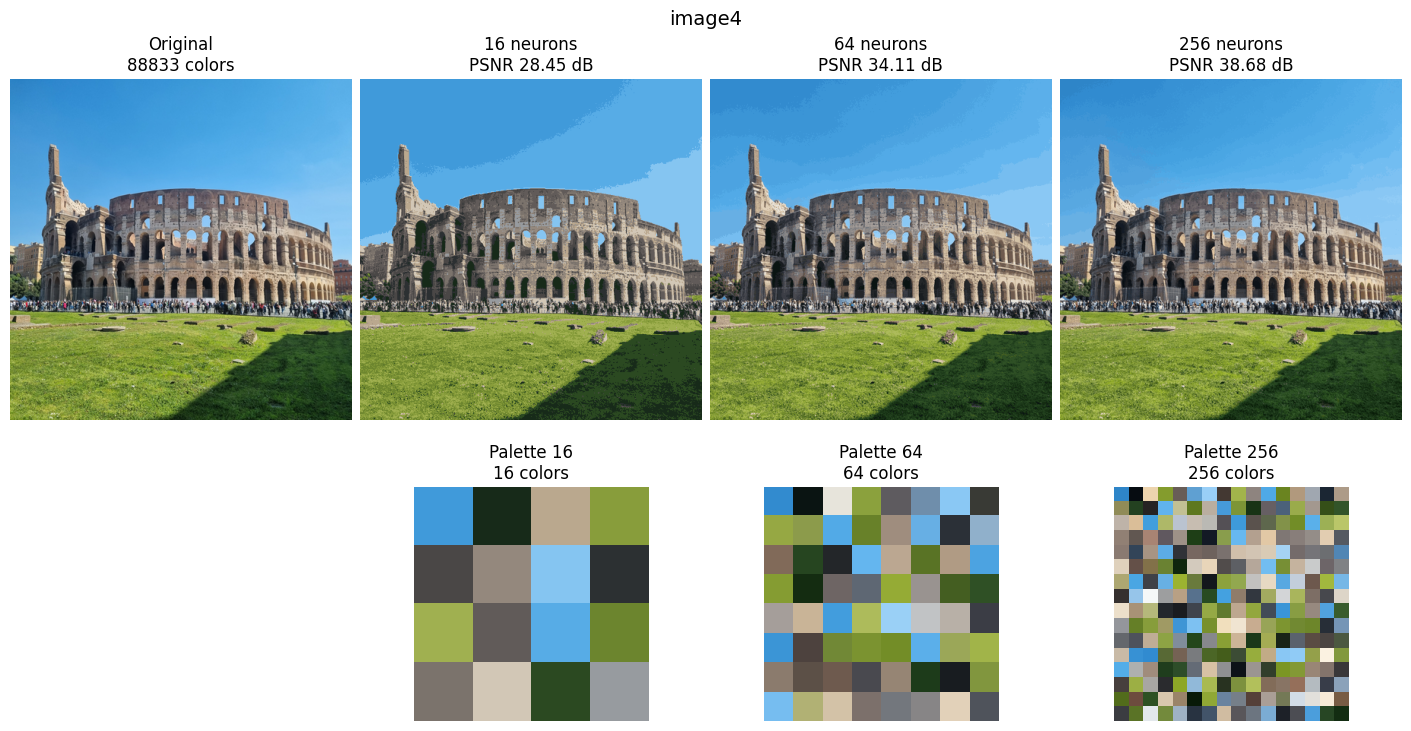

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/image4.png

=== image5.jpg (450, 450) samples=(202500, 3) ===

training 16 neurons
alive units: 16
quantization error: 0.0403
MSE: 0.000784
PSNR: 31.06 dB
colors: 55122 -> 16

training 64 neurons
alive units: 64
quantization error: 0.0213
MSE: 0.000219
PSNR: 36.60 dB
colors: 55122 -> 64

training 256 neurons
alive units: 256
quantization error: 0.0133
MSE: 0.000080
PSNR: 40.95 dB
colors: 55122 -> 244


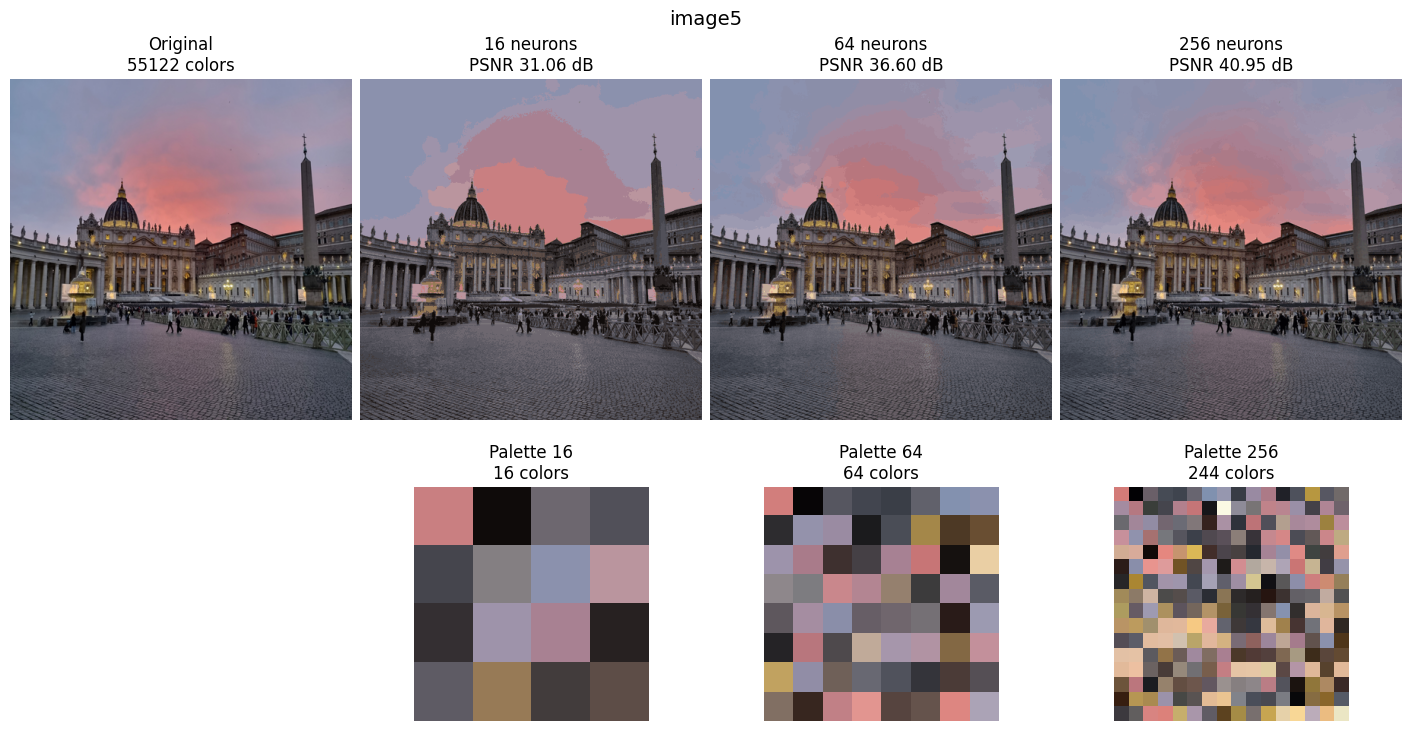

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/image5.png

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/metrics.csv (15 runs)


In [3]:
metrics = []

for image_path in image_paths:
    image, pixels, samples = load_image(image_path)
    print(f"\n=== {image_path.name} {image.size} samples={samples.shape} ===")
    image_runs = []

    for max_neurons in MAX_NEURONS:
        print(f"\ntraining {max_neurons} neurons")
        gng = train_gng(samples, max_neurons)
        result = measure(gng, samples, pixels)

        record = {
            "image": image_path.stem,
            "neurons": max_neurons,
            "quantization_error": result["quantization_error"],
            "mse": result["mse"],
            "psnr": result["psnr"],
            "original_colors": result["original_colors"],
            "used_colors": result["used_colors"],
        }
        metrics.append(record)
        image_runs.append(result | {"neurons": max_neurons})
        save_metrics(metrics)

        print(f"alive units: {result['n_nodes']}")
        print(f"quantization error: {record['quantization_error']:.4f}")
        print(f"MSE: {record['mse']:.6f}")
        print(f"PSNR: {record['psnr']:.2f} dB")
        print(f"colors: {record['original_colors']} -> {record['used_colors']}")

    figure_path = show_image_results(image, image_path.stem, image_runs)
    print(f"saved {figure_path}")

print(f"\nsaved {RESULTS_DIR / 'metrics.csv'} ({len(metrics)} runs)")


## Plotting the results comparison


image                   neurons       QE        MSE     PSNR           colors
image1                       16   0.0636   0.001923    27.16  88207 -> 16   
image1                       64   0.0322   0.000480    33.19  88207 -> 64   
image1                      256   0.0207   0.000183    37.37  88207 -> 244  
image2                       16   0.0550   0.001303    28.85  81581 -> 16   
image2                       64   0.0285   0.000340    34.68  81581 -> 64   
image2                      256   0.0170   0.000118    39.28  81581 -> 251  
image3                       16   0.0518   0.001209    29.17  73373 -> 16   
image3                       64   0.0270   0.000313    35.04  73373 -> 64   
image3                      256   0.0153   0.000099    40.05  73373 -> 256  
image4                       16   0.0565   0.001428    28.45  88833 -> 16   
image4                       64   0.0288   0.000388    34.11  88833 -> 64   
image4                      256   0.0169   0.000135    38.68  88833 -> 256 

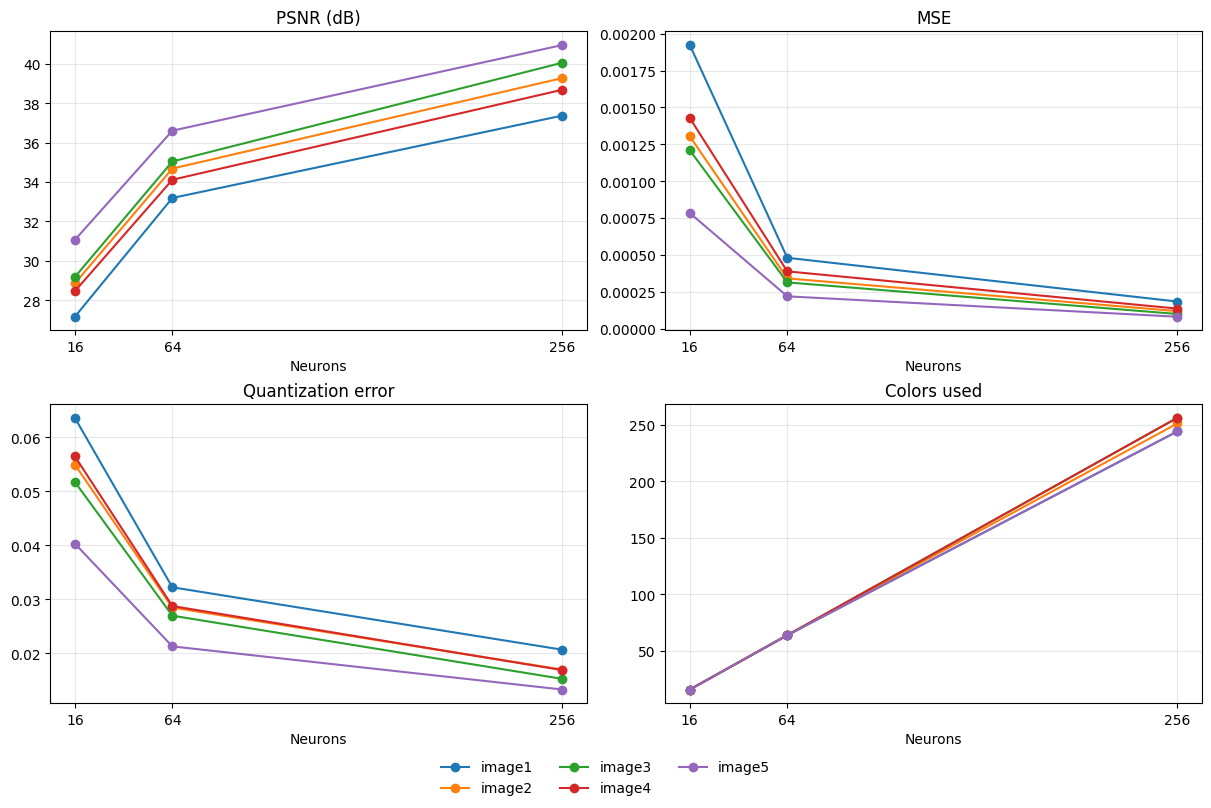

saved /mnt/hdd/home/gbonavina/GitHub/projeto-2-rna/gng/results_gng/metrics_comparison.png


In [4]:
metrics_path = RESULTS_DIR / "metrics.csv"
if not metrics_path.exists():
    raise FileNotFoundError("Run the training cell first. metrics.csv was not found.")

loaded = load_metrics(metrics_path)
images = list(dict.fromkeys(row["image"] for row in loaded))

print(
    f"{'image':<22} {'neurons':>8} {'QE':>8} {'MSE':>10} {'PSNR':>8} {'colors':>16}"
)
for row in loaded:
    print(
        f"{row['image']:<22} {row['neurons']:>8} "
        f"{row['quantization_error']:8.4f} {row['mse']:10.6f} {row['psnr']:8.2f} "
        f"{row['original_colors']:>6} -> {row['used_colors']:<5}"
    )

panels = [
    ("psnr", "PSNR (dB)"),
    ("mse", "MSE"),
    ("quantization_error", "Quantization error"),
    ("used_colors", "Colors used"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
for ax, (key, title) in zip(axes.ravel(), panels):
    for name in images:
        rows = sorted(
            (row for row in loaded if row["image"] == name),
            key=lambda row: row["neurons"],
        )
        ax.plot(
            [row["neurons"] for row in rows],
            [row[key] for row in rows],
            marker="o",
            label=name,
        )
    ax.set_title(title)
    ax.set_xlabel("Neurons")
    ax.set_xticks(MAX_NEURONS)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncol=3, frameon=False)

plot_path = RESULTS_DIR / "metrics_comparison.png"
fig.savefig(plot_path, dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)
print(f"saved {plot_path}")
